# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Rasendriya Nandana Kurniawan
- **Email:** rasenkurniawan@gmail.com
- **ID Dicoding:** @rnk123

## Menentukan Pertanyaan Bisnis

- Bagaimana profil dan karakteristik penyewaan sepeda bila dilakukan segmentasi dataset berdasarkan temperatur udara?
- Kapan rentang waktu yang paling ideal bagi penyewa sepeda, serta bagaimana distribusi penggunanya pada saat jam sibuk dibanding dengan jam istirahat

## Import Semua Packages/Library yang Digunakan

In [21]:
# Memanggil Package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
%matplotlib inline
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data

In [22]:
# Memanggil dataset day.csv
day_df = pd.read_csv("data\day.csv")
day_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [23]:
# Memanggil dataset hour.csv
hour_df = pd.read_csv("data\hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- "Bike Sharing" Datasets dari Fanaee-T, Hadi, dan Gama, Joao merupakan data yang mengkoleksi kondisi iklim, waktu, musim, beserta jumlah akun yang tercatat dalam program "Bike Sharing"
- Kedua dataset tersebut hanya memiliki 1 perbedaan dalam struktur kolom data, yaitu pada tabel hour_df mencantumkan data per jamnya sesuai dengan kolom data "hr", sedangkan day_df tidak mencantumkan data per jam-nya, melainkan hanya per hari

### Assessing Data

Melakukan assessing dataset day.csv

In [24]:
# Cek info dataset
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [25]:
# Cek keunikan dataset
day_df.nunique()

instant       731
dteday        731
season          4
yr              2
mnth           12
holiday         2
weekday         7
workingday      2
weathersit      3
temp          499
atemp         690
hum           595
windspeed     650
casual        606
registered    679
cnt           696
dtype: int64

In [26]:
# Cek duplikasi data beserta missing value
print("\nJumlah Data yang Terduplikat: ", day_df.duplicated().sum())
print("\nJumlah Data yang NA:"); day_df.isna().sum()


Jumlah Data yang Terduplikat:  0

Jumlah Data yang NA:


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [27]:
# Cek statistik deskriptif
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Melakukan assessing dataset hour_df

In [28]:
# Cek info dataset
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [29]:
# Cek keunikan dataset
hour_df.nunique()

instant       17379
dteday          731
season            4
yr                2
mnth             12
hr               24
holiday           2
weekday           7
workingday        2
weathersit        4
temp             50
atemp            65
hum              89
windspeed        30
casual          322
registered      776
cnt             869
dtype: int64

In [30]:
# Cek duplikasi data beserta missing value
print("Jumlah Data yang Terduplikat: ", hour_df.duplicated().sum())
print("\nJumlah Data yang NA:"); hour_df.isna().sum()

Jumlah Data yang Terduplikat:  0

Jumlah Data yang NA:


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [31]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**

Berdasarkan hasil asesmen data yang dilakukan, ada beberapa kesimpulan yang didapatkan:
- Tidak ada permasalahan data dasar, seperti jumlah data yang terduplikat dan jumlah data yang missing, sehingga tidak diperlukan perbaikan dataset dengan cleaning ataupun dengan pengisian nilai pada data yang kosong
- Nilai mean dan standar deviasi tidak berlaku pada variabel "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", dan "weathersit". Hal tersebut bisa disimpulkan karena variabel tersebut hanya bisa diinput dengan data yang bersifat kategorikal, sehingga mean dan standar deviasi tidak bisa dilakukan perhitungan.

### Cleaning Data

In [32]:
# 1. Cek Total Baris per dataset
print("\n---------------- Sebelum cleaning -----------------")
print(f"Total Baris dataset day_df sebelum cleaning: {len(day_df)}")
print(f"Total Baris dataset hour_df sebelum cleaning: {len(hour_df)}")

# 2. Menghapus Duplikasi
day_df_dup = day_df.drop_duplicates()
hour_df_dup = hour_df.drop_duplicates()

# 3. Menghapus Missing Values
day_df= day_df_dup.dropna()
hour_df = hour_df_dup.dropna()

# 4. Verifikasi Akhir
print("\n---------------- Sesudah cleaning -----------------")
print(f"Total Baris dataset day_df setelah cleaning: {len(day_df)}")
print(f"Total Baris dataset hour_df setelah cleaning: {len(hour_df)}")


---------------- Sebelum cleaning -----------------
Total Baris dataset day_df sebelum cleaning: 731
Total Baris dataset hour_df sebelum cleaning: 17379

---------------- Sesudah cleaning -----------------
Total Baris dataset day_df setelah cleaning: 731
Total Baris dataset hour_df setelah cleaning: 17379


**Insight:**
- Karena memang tidak ada kendala missing value ataupun duplicated data, maka proses cleaning data tidak akan memengaruhi ataupun merubah dataset yang digunaka

## Exploratory Data Analysis (EDA)

### Eksplorasi Dataset day_df


Matriks Korelasi Pearson Faktor Cuaca vs Total Penyewaan

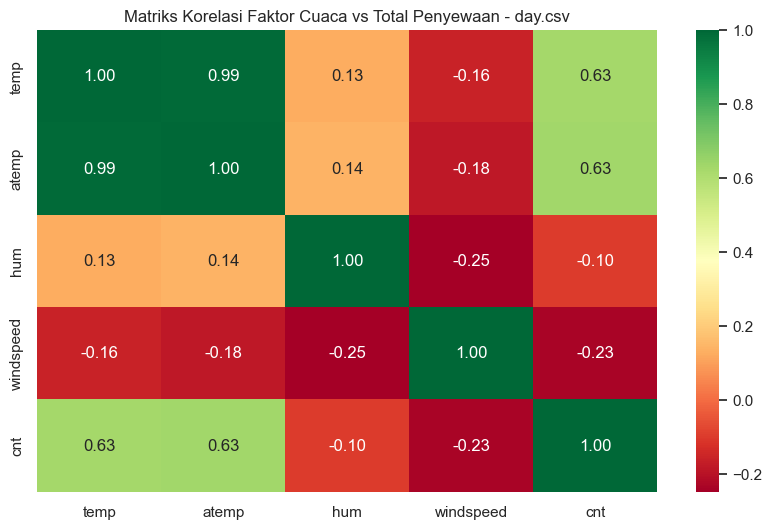

In [33]:
plt.figure(figsize=(10, 6))
corr_matrix = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Matriks Korelasi Faktor Cuaca vs Total Penyewaan - day.csv')
plt.show()

Boxplot Distribusi Total Penyewaan Berdasarkan Musim Penyewaan

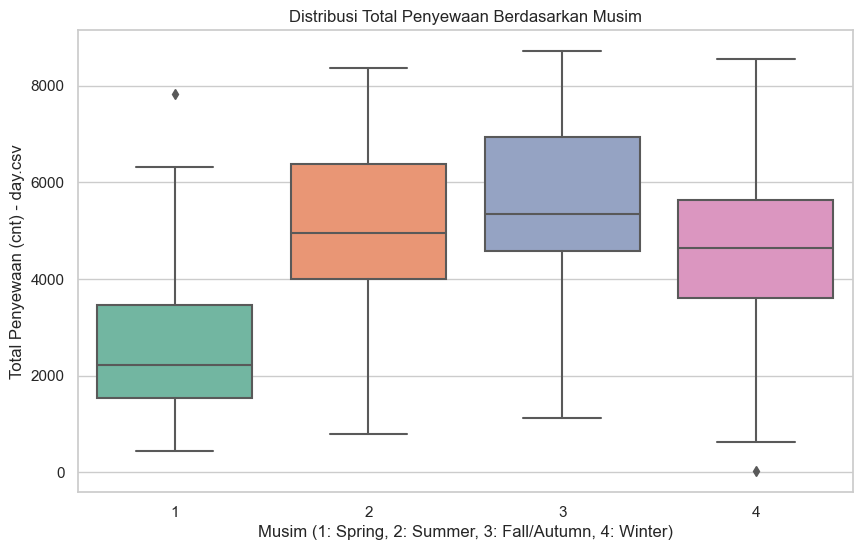

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=day_df, x='season', y='cnt', palette='Set2')
plt.title('Distribusi Total Penyewaan Berdasarkan Musim')
plt.xlabel('Musim (1: Spring, 2: Summer, 3: Fall/Autumn, 4: Winter)')
plt.ylabel('Total Penyewaan (cnt) - day.csv')
plt.show()

Komposisi Pengguna: Perbandingan antara Casual dengan Registered user berdasarkan hari

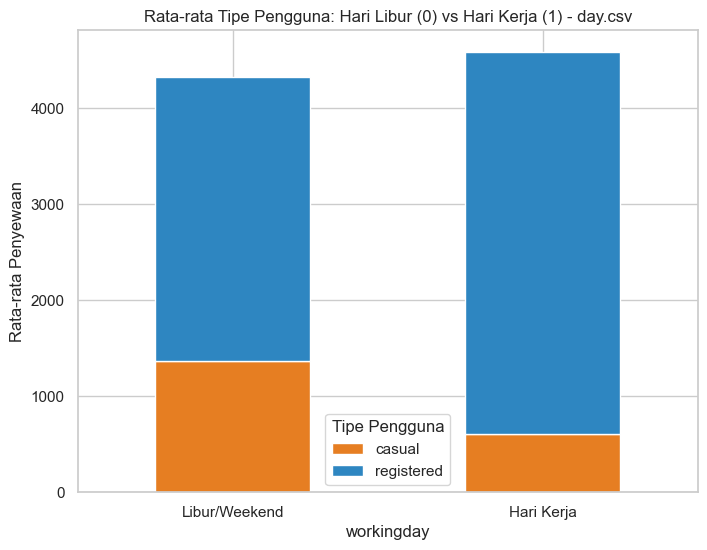

In [35]:
# Kelompokkan rata-rata casual dan registered berdasarkan workingday
user_type_gap = day_df.groupby('workingday')[['casual', 'registered']].mean()

user_type_gap.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#E67E22', '#2E86C1'])
plt.title('Rata-rata Tipe Pengguna: Hari Libur (0) vs Hari Kerja (1) - day.csv')
plt.xticks(ticks=[0, 1], labels=['Libur/Weekend', 'Hari Kerja'], rotation=0)
plt.ylabel('Rata-rata Penyewaan')
plt.legend(title='Tipe Pengguna')
plt.show()

### Eksplorasi Dataset "hour.csv"

Matriks Korelasi Pearson Faktor Cuaca vs Total Penyewaan


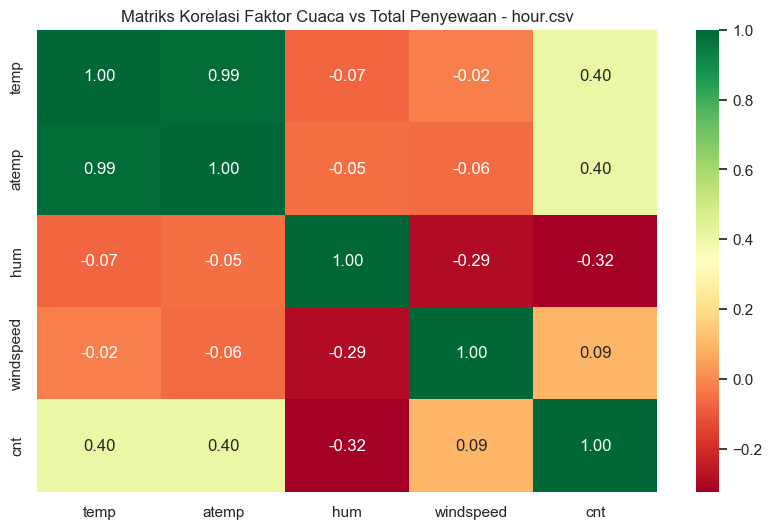

In [36]:
plt.figure(figsize=(10, 6))
corr_matrix = hour_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Matriks Korelasi Faktor Cuaca vs Total Penyewaan - hour.csv')
plt.show()

Boxplot Distribusi Total Penyewaan Berdasarkan Musim Penyewaan


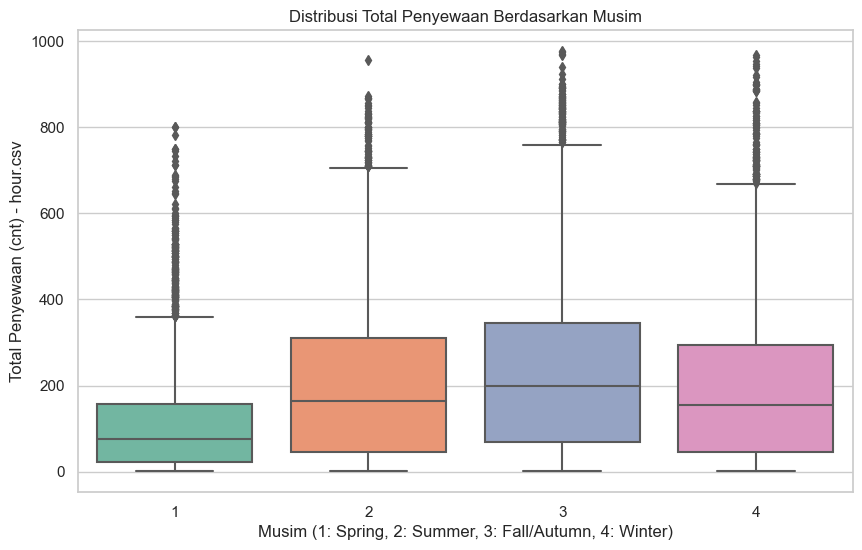

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=hour_df, x='season', y='cnt', palette='Set2')
plt.title('Distribusi Total Penyewaan Berdasarkan Musim')
plt.xlabel('Musim (1: Spring, 2: Summer, 3: Fall/Autumn, 4: Winter)')
plt.ylabel('Total Penyewaan (cnt) - hour.csv')
plt.show()

Komposisi Pengguna: Perbandingan antara Casual dengan Registered user berdasarkan hari

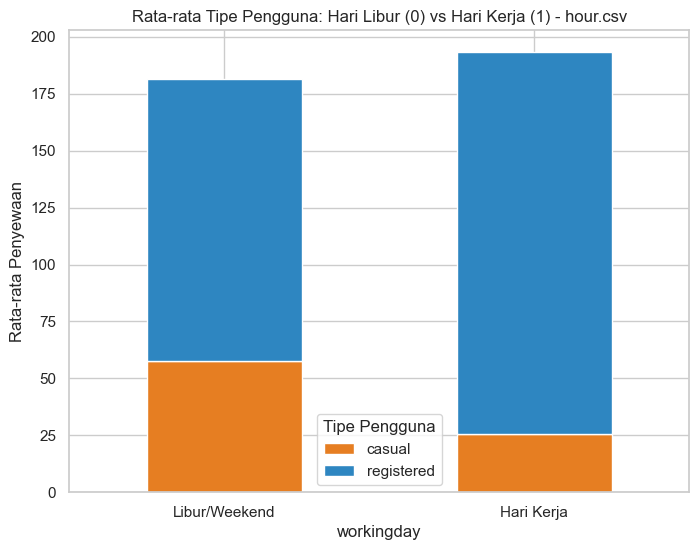

In [38]:
# Kelompokkan rata-rata casual dan registered berdasarkan workingday
user_type_gap = hour_df.groupby('workingday')[['casual', 'registered']].mean()

user_type_gap.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#E67E22', '#2E86C1'])
plt.title('Rata-rata Tipe Pengguna: Hari Libur (0) vs Hari Kerja (1) - hour.csv')
plt.xticks(ticks=[0, 1], labels=['Libur/Weekend', 'Hari Kerja'], rotation=0)
plt.ylabel('Rata-rata Penyewaan')
plt.legend(title='Tipe Pengguna')
plt.show()

**Insight:**

Adapun insight yang didapatkan dari hasil EDA tersebut pada kedua dataset adalah sebagai berikut:
- Korelasi "temp" dan "atemp" memiliki korelasi yang cenderung sama terhadap total penyewa sepeda dikarenakan keduanya berdasarkan pada 1 hal yang sama, yaitu suhu pada waktu tersebut. Hal tersebut juga bisa terlihat lewat korelasi antara variabel "temp" dengan "atemp" pada kedua dataset tersebut yang masing-masing bernilai 0.99, mengindikasikan adanya korelasi hampir sempurna antar variabel tersebut, sehingga ada baiknya salah satu dari dua variabel tersebut tidak digunakan agar tidak menciptakan adanya masalah multikolinieritas.
- Mengenai distribusi total penyewaan sepeda per musim, terlihat ada pola pada kedua dataset tersebut, dimulai dengan penyewaan sepeda pada musim semi (spring) yang paling sedikit, terlihat dari nilai median dan ukuran boxplot yang cenderung kecil, lalu total penyewaan mulai bertumbuh pada musim panas (summer) dan mencapai puncaknya pada musim gugur (fall/autumn), lalu menurun pada musim salju (winter).
- Rata-rata total penyewaan sepeda cenderung lebih banyak terjadi pada saat hari kerja dibandingkan dengan saat hari libur. Namun demikian, penyewaan sepeda secara kasual terjadi lebih banyak pada waktu libur/weekend dibandingkan pada saat hari kerja.


## Visualization & Explanatory Analysis

Metode analisis lanjutan dilakukan dengan clustering method. Tujuan dari penggunaan clustering method untuk dataset bike sharing adalah untuk mengetahui bagaimana ciri khas suatu kelompok data dengan kategori tertentu guna mendapatkan kesimpulan kondisi apa yang paling ideal untuk meningkatkan jumlah penyewaan sepedea


### Pertanyaan 1: Bagaimana profil dan karakteristik penyewaan sepeda bila dilakukan segmentasi dataset berdasarkan temperatur udara?

Dataset "day.csv"

In [39]:
# 1. Pastikan kolom temp_bin sudah dibuat
def suhu_category(temp):
    if temp < 0.3:
        return 'Cold'
    elif 0.3 <= temp < 0.6:
        return 'Pleasant'
    else:
        return 'Hot'

day_df['temp_bin'] = day_df['temp'].apply(suhu_category)

# 2. Analisis Manual Grouping dengan statistik lengkap secara vertikal
manual_stats_vertical = day_df.groupby('temp_bin').agg({
    'temp': ['min', 'mean', 'max'],
    'hum': ['min', 'mean', 'max'],
    'windspeed': ['min', 'mean', 'max'],
    'casual': ['min', 'mean', 'max'],
   'registered': ['min', 'mean', 'max'],
    'cnt': ['min', 'mean', 'max'],
}).reindex(['Cold', 'Pleasant', 'Hot']).T  # Transpose ke vertikal

# 3. Pembulatan agar bersih
manual_stats_vertical = manual_stats_vertical.round(4)

print("--- PROFIL MANUAL BINNING (VERTICAL VIEW) ---")
display(manual_stats_vertical)

--- PROFIL MANUAL BINNING (VERTICAL VIEW) ---


temp_bin              Cold   Pleasant        Hot
temp       min      0.0591     0.3000     0.6000
           mean     0.2367     0.4433     0.7004
           max      0.2992     0.5992     0.8617
hum        min      0.3022     0.0000     0.3050
           mean     0.5734     0.6419     0.6374
           max      0.9292     0.9704     0.9725
windspeed  min      0.0454     0.0224     0.0504
           mean     0.2002     0.1985     0.1747
           max      0.4216     0.5075     0.3756
casual     min      9.0000     2.0000   153.0000
           mean   230.1128   795.3324  1241.6196
           max    981.0000  3252.0000  3410.0000
registered min    416.0000    20.0000   889.0000
           mean  2158.6165  3666.5510  4423.2902
           max   5306.0000  6917.0000  6946.0000
cnt        min    431.0000    22.0000  1115.0000
           mean  2388.7293  4461.8834  5664.9098
           max   5686.0000  8555.0000  8714.0000

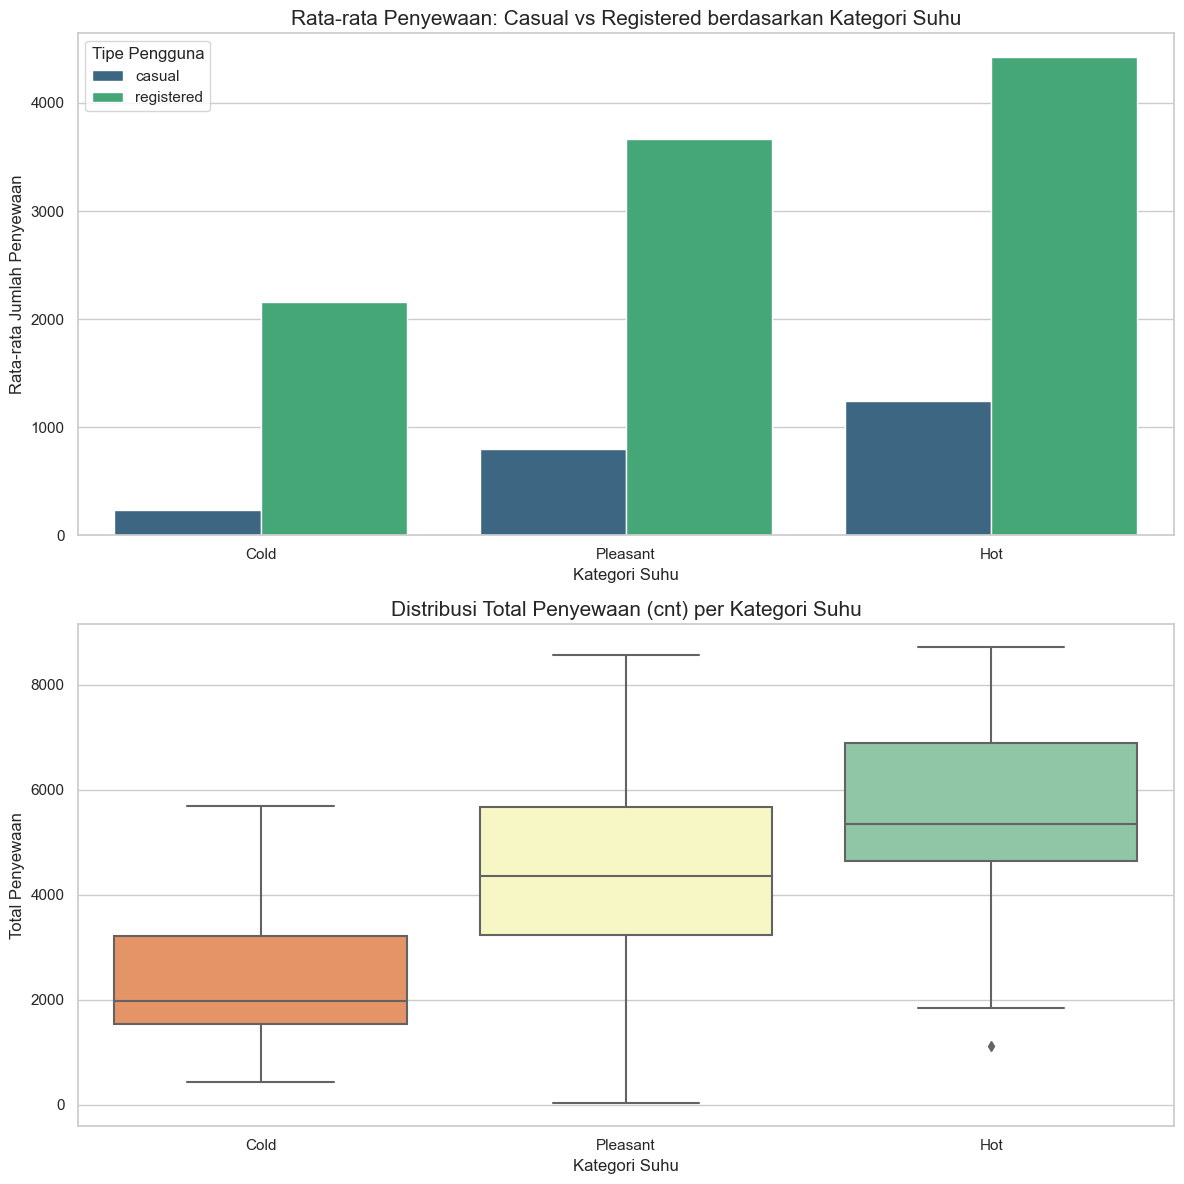

In [41]:
# 1. Mengatur urutan kategori agar konsisten di grafik
category_order = ['Cold', 'Pleasant', 'Hot']
day_df['temp_bin'] = pd.Categorical(day_df['temp_bin'], categories=category_order, ordered=True)

# Menyiapkan canvas dengan 2 baris dan 1 kolom
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))

# --- GRAFIK 1: Rata-rata Penyewaan per Kategori Suhu (Casual vs Registered) ---
# Kita perlu mengubah format data ke 'long-format' untuk visualisasi perbandingan
df_melted = day_df.melt(id_vars='temp_bin', value_vars=['casual', 'registered'], 
                        var_name='user_type', value_name='avg_rentals')

sns.barplot(
    data=df_melted, 
    x='temp_bin', 
    y='avg_rentals', 
    hue='user_type', 
    ax=ax[0], 
    palette='viridis',
    errorbar=None # Menghilangkan garis error agar fokus ke rata-rata
)
ax[0].set_title('Rata-rata Penyewaan: Casual vs Registered berdasarkan Kategori Suhu', fontsize=15)
ax[0].set_xlabel('Kategori Suhu', fontsize=12)
ax[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
ax[0].legend(title='Tipe Pengguna')

# --- GRAFIK 2: Distribusi Total Penyewaan (Boxplot) ---
sns.boxplot(
    data=day_df, 
    x='temp_bin', 
    y='cnt', 
    ax=ax[1], 
    palette='Spectral'
)
ax[1].set_title('Distribusi Total Penyewaan (cnt) per Kategori Suhu', fontsize=15)
ax[1].set_xlabel('Kategori Suhu', fontsize=12)
ax[1].set_ylabel('Total Penyewaan', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:**
- Dengan melakukan segmentasi temperatur ke dalam 3 klaster yang berbeda, dapat terlihat bahwa semakin tinggi temperatur, semakkin rendah tingkat kelembaban udara serta kecepatan angin. Tetapi selain dari itu, terlihat pula bahwa ada peningkatan signifikan pada jumlah penyewa.
- Hasil ini dapat menjadi sebuah gambaran bagi perusahaan agar dapat memaksimalkan stok sepeda yang tersedia untuk disewakan pada saat cuaca cenderung hangat atau panas serta minim kelembaban dan angin yang lebih santai, mengingat ada lonjakan pengguna dari temperatur rendah (dingin) ke temperatur sedang, dengan peningkatan jumlah pengguna kasual dari 230 menjadi 795, pengguna reguler dari 2158 menjadi 3666, dengan total peningkatan jumlah penyewa dari 2388 menjadi 4461. Hal tersebut juga terjadi apabila membandingkan antara jumlah pengguna saat temperatur sedang dengan temperatur tinggi.

### Pertanyaan 2: Kapan rentang waktu yang paling ideal bagi penyewa sepeda, serta bagaimana distribusi penggunanya pada saat jam sibuk dibanding dengan jam istirahat?

Dataset "hour.csv"

In [40]:
# 1. Membuat fungsi kategori waktu
def hour_category(hr):
    if 0 <= hr <= 6:
        return 'Dini Hari'
    elif 7 <= hr <= 15:
        return 'Pagi-Siang'
    elif 16 <= hr <= 19:
        return 'Sore'
    else:
        return 'Malam'

# 2. Menerapkan binning pada hour_df
hour_df['time_bin'] = hour_df['hr'].apply(hour_category)

# 3. Analisis Manual Grouping (Statistik Cuaca & Pengguna)
manual_hour_stats = hour_df.groupby('time_bin').agg({
    'temp': ['min', 'mean', 'max'],
    'hum': ['min', 'mean', 'max'],
    'windspeed': ['min', 'mean', 'max'],
    'casual': ['min', 'mean', 'max'],
    'registered': ['min', 'mean', 'max'],
    'cnt': ['min', 'mean', 'max']
}).reindex(['Dini Hari', 'Pagi-Siang', 'Sore', 'Malam']).T # Transpose agar vertikal

# 4. Pembulatan hasil
manual_hour_stats = manual_hour_stats.round(4)

print("--- PROFIL MANUAL BINNING WAKTU (hour_df) ---")
display(manual_hour_stats)

--- PROFIL MANUAL BINNING WAKTU (hour_df) ---


time_bin         Dini Hari  Pagi-Siang      Sore     Malam
temp       min      0.0200      0.0200    0.0800    0.0400
           mean     0.4500      0.5137    0.5462    0.4909
           max      0.8200      0.9600    1.0000    0.9200
hum        min      0.0000      0.0000    0.0000    0.0000
           mean     0.7243      0.5910    0.5294    0.6399
           max      1.0000      1.0000    1.0000    1.0000
windspeed  min      0.0000      0.0000    0.0000    0.0000
           mean     0.1557      0.2052    0.2264    0.1789
           max      0.7761      0.8060    0.8507    0.8060
casual     min      0.0000      0.0000    0.0000    0.0000
           mean     4.4575     51.2148   64.4907   25.4852
           max     68.0000    362.0000  367.0000  237.0000
registered min      0.0000      1.0000    8.0000    2.0000
           mean    27.8642    190.0556  313.1392  128.8925
           max    234.0000    808.0000  886.0000  461.0000
cnt        min      1.0000      1.0000   11.0000    2.0000
           mean    32.3217    241.2704  377.6300  154.3777
           max    283.0000    839.0000  977.0000  584.0000

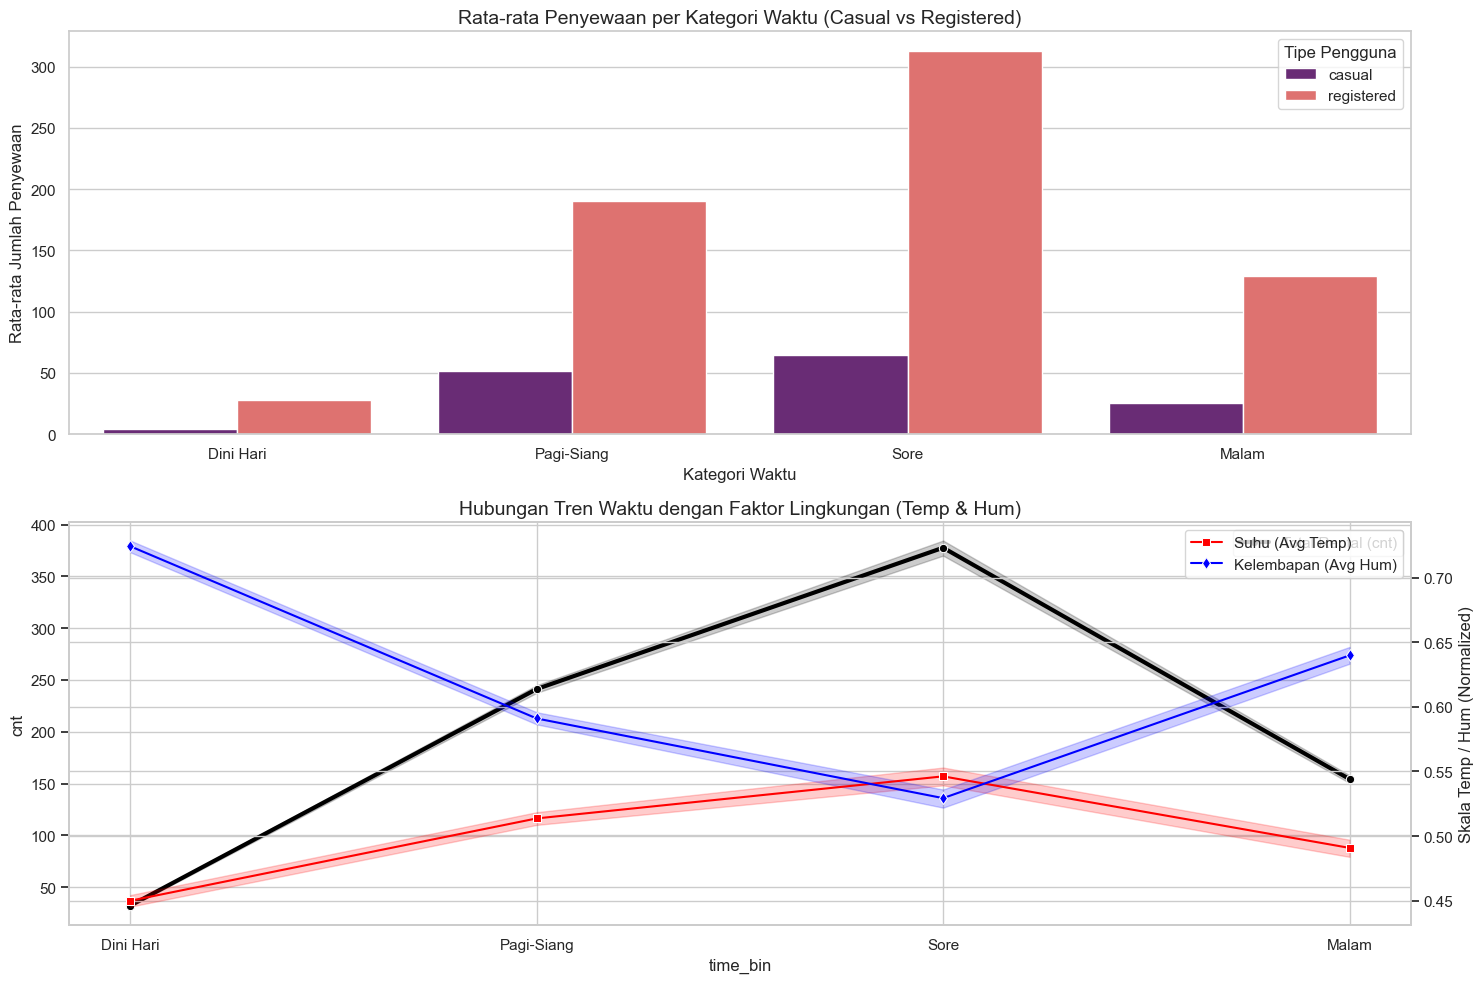

In [42]:
# 1. Pastikan urutan kategori logis (sesuai waktu)
time_order = ['Dini Hari', 'Pagi-Siang', 'Sore', 'Malam']
hour_df['time_bin'] = pd.Categorical(hour_df['time_bin'], categories=time_order, ordered=True)

# Menyiapkan kanvas
plt.figure(figsize=(15, 10))

# --- GRAFIK 1: Perbandingan Casual vs Registered Berdasarkan Waktu ---
plt.subplot(2, 1, 1)
df_hour_melted = hour_df.melt(id_vars='time_bin', value_vars=['casual', 'registered'], 
                              var_name='user_type', value_name='avg_rentals')

sns.barplot(
    data=df_hour_melted, 
    x='time_bin', 
    y='avg_rentals', 
    hue='user_type', 
    palette='magma',
    errorbar=None
)
plt.title('Rata-rata Penyewaan per Kategori Waktu (Casual vs Registered)', fontsize=14)
plt.xlabel('Kategori Waktu', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.legend(title='Tipe Pengguna')

# --- GRAFIK 2: Pengaruh Kelembapan (Hum) & Suhu (Temp) terhadap Total Penyewaan ---
# Menggunakan Lineplot untuk melihat tren faktor lingkungan di tiap blok waktu
plt.subplot(2, 1, 2)
sns.lineplot(
    data=hour_df, 
    x='time_bin', 
    y='cnt', 
    marker='o', 
    label='Total Rental (cnt)', 
    color='black', 
    linewidth=3
)
ax2 = plt.gca().twinx() # Membuat sumbu Y kedua untuk faktor lingkungan
sns.lineplot(
    data=hour_df, 
    x='time_bin', 
    y='temp', 
    marker='s', 
    label='Suhu (Avg Temp)', 
    color='red', 
    ax=ax2
)
sns.lineplot(
    data=hour_df, 
    x='time_bin', 
    y='hum', 
    marker='d', 
    label='Kelembapan (Avg Hum)', 
    color='blue', 
    ax=ax2
)

plt.title('Hubungan Tren Waktu dengan Faktor Lingkungan (Temp & Hum)', fontsize=14)
plt.xlabel('Kategori Waktu', fontsize=12)
ax2.set_ylabel('Skala Temp / Hum (Normalized)', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Insight:**
- Pengelompokkan total penyewaan berdasarkan waktu menunjukkan bahwa segmen sore menjadi waktu dengan rata-rata penyewaan sepeda per jam terbanyak, diikuti oleh saat periode pagi-siang, lalu malam hari, dan dini hari dengan rata-rata total penyewa paling sedikit.
- Pengelompokan berdasarkan rentang waktu ini menunjukkan bahwa waktu sangat berperan penting bagi pengguna kasual untuk menyewa sepeda. Hal ini terlihat rata-rata jumlah pengguna registered per jamnya mencapai lebih 6 kali lipat, lalu diikuti pada waktu malam hari, kemudian pada waktu sore hari, dan waktu pagi-sore menjadi waktu dengan perbandingan paling kecil. Hal ini menunjukkan bahwa waktu menjadi aspek yang sangat menentukan bagi pengguna kasual untuk mementukan apakah akan menyewa sepeda atau tidak.

## Conclusion

- Analisis Penyewaan Sepeda ini menunjukkan bahwa suhu dan waktu adalah dua faktor utama yang memengaruhi seseorang dalam menyewa sepeda. Adapun kondisi yang ideal bagi seseorang untuk menyewa sepeda adalah ketika cuaca cenderung lebih hangat, kelembaban udara rendah, angin yang lebih santai, serta waktu sore menuju malam, serta kondisi yang paling tidak ideal bagi seseorang untuk menyewa sepeda adalah ketika cuaca cenderung lebih dingin, angin kencang, kelembaban udara yang tinggi, serta waktu dini hari sampai pagi.
- Pengguna kasual cenderung memerhatikan kondisi cuaca harian serta jam-jam yang mendukung untuk menyewa sepeda. Berbeda dengan pengguna langganan yang lebih loyal dalam menyewa sepeda, meski salah satu ataupun semua faktor utamanya dirasa kurang ideal.
- Perusahaan dapat melakukan redistribusi sepeda pada stasiun atau halte pada area residensial sebelum jam 07:00 dan pada daerah perkantoran sebelum jam 16:00 mengingat periode tersebut merupakan waktu terbaik bagi orang untuk menyewa sepeda.
- Pada waktu diluar jam kerja atau cuaca yang buruk, periode tersebut dapat dimanfaatkan sebagai waktu untuk pengecekan serta perbaikan fasilitas sepeda sewaan mengingat jumlah penyewaan sepeda tidak akan sebanyak pada waktu seperti biasanya.